<a href="https://colab.research.google.com/github/cabreonictor/Ciencia-de-Datos-y-Optimizacion-de-Modelos/blob/main/Modelado_de_Sistemas_de_IA_Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Integrador Final TIF - Avance 2**
## *Sistema de ML para evaluar la influencia de los distintos manejos agronómicos en el rendimiento del cultivo de maní*
### **Integrantes**: Jimena Lasci - Angeles Deluca - Lucio Mamani

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

URL = ('https://github.com/cabreonictor/Modelado-de-IA-Aplicada/raw/refs/heads/main/Dataset.xlsx')
df = pd.read_excel(URL)
print(df.columns)
df.head()

Index(['Denominación de muestras', 'Lote', 'Ubicación', 'Zona',
       'Fecha de Siembra', 'Cultivar', 'Tamaño', 'Campañas sin maní',
       'Antecesor', 'Tipo de Labranza',
       'TIPO DE DISTRIBUIDOR SE UTILIZO EN LA SIEMBRA',
       ' SEMBRADORA\nIndique marca', 'UTILIZO PILOTO AUTOMATICO',
       'DENSIDAD DE SIEMBRA\nSemillas por metro',
       'LA SEMILLA FUE TRATADA CON POLIMEROS',
       'LA SEMILLA FUE TRATADA CON BIOESTIMULANTES', 'Utilizó INOCULANTE',
       'Si la respuesta anterior fue SI, indique el método de aplicación utilizado',
       'PULVERIZADOR\nIndique marca y modelo utilizado',
       'Tipo de PULVERIZADOR :', 'Cuantas Aplicaciones de Fungicidas',
       'Fecha arrancado', 'Arrancadora', 'uso de piloto', 'Precipitaciones',
       'Fecha Cosecha', 'Cosechadora', 'Tipo de Cosechadora', 'Rto Vaina (qq)',
       'Rto grano (qq)', 'Nitrogeno (%)', 'Azufre (mg/kg)', 'Boro  (mg/kg)',
       'Calcio  (mg/kg)', 'Zinc (mg/kg)', 'Fosforo (mg/kg)', 'Hierro (mg/kg)',
      

,Denominación de muestras,Lote,Ubicación,Zona,Fecha de Siembra,Cultivar,Tamaño,Campañas sin maní,Antecesor,Tipo de Labranza,...,Rto grano (qq),Nitrogeno (%),Azufre (mg/kg),Boro (mg/kg),Calcio (mg/kg),Zinc (mg/kg),Fosforo (mg/kg),Hierro (mg/kg),Magnesio (mg/kg),Potasio (mg/kg)
0,179,1,Ameghino,SE,2QOct,asem 353,40/50,NUNCA MANI,SOJA,CONVENCIONAL (Especificar labores: rastra disco),...,39.5,4.85,2488,30.0,2720,42.0,5138,373,2052,10260
1,27,4,General Deheza,N,2QOct,ec 420,40/50,4 años,SOJA,directa,...,46,4.96,299,25.9,2618,36.8,363,354,1583,7002
2,44,6,Tancacha,N,2QOct,ec 394,50/60,4 años,SOJA,directa,...,21,4.99,1884,30.0,3523,35.8,4715,834,1867,7717
3,26,8,Hernando,N,1QOct.,ec max,38/42,5 años,SOJA,"MINIMA (VERTICAL: paratil, carpitec)",...,63,4.97,1974,29.5,3143,35.4,4065,1415,1549,6680
4,87,10,Carnerillo,N,2QOct,ec 394,40/50,4 años,SOJA,"MINIMA (VERTICAL: paratil, carpitec)",...,48,4.99,1733,27.0,3558,31.5,4891,376,1805,7583


## Gráfico de dispersión de las posibles variables de interés


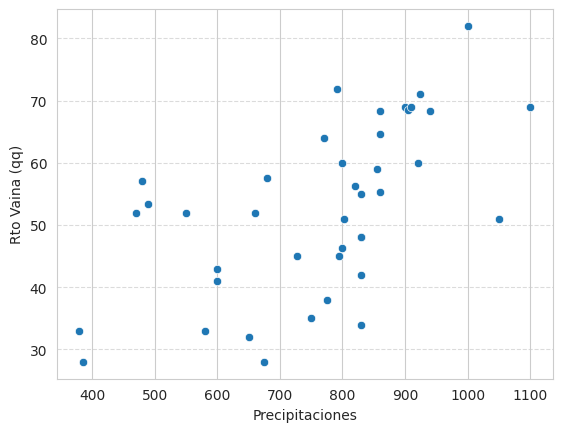

In [19]:
df['Precipitaciones'] = pd.to_numeric(df['Precipitaciones'], errors='coerce')
sns.scatterplot(data=df, x="Precipitaciones", y="Rto Vaina (qq)")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


Se puede observar que tiene una cierta tendencia lineal, por lo que es una variable que va a contribuir al modelo.

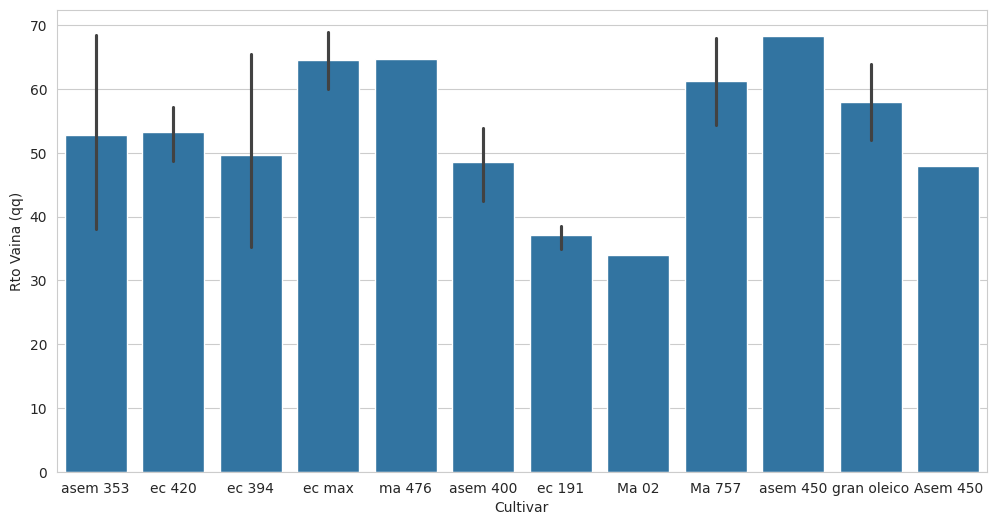

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Cultivar", y="Rto Vaina (qq)", data=df)
plt.show()

Se puede observar que hay cierto tipos de grano de maní que producen mayor rendimientos que otros

## Modelo: Random Forest

In [21]:
# ==========================================
# 1. ENTRENAMIENTO DEL MODELO BASE
# ==========================================

# 1. Eliminar espacios en blanco
df.columns = df.columns.str.strip()

# --- PASO DE LIMPIEZA CRÍTICO ---
# Convertimos las columnas de texto a MAYÚSCULAS y removemos espacios rebeldes
# Así 'directa', 'Directa' y 'DIRECTA' se transforman en una sola categoría: 'DIRECTA'
columnas_texto_a_limpiar = ['Zona', 'Tipo de Labranza', 'Cultivar', 'Antecesor']

for col in columnas_texto_a_limpiar:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().str.strip()
        # Reemplazar textos similares si es necesario (ej. simplificar labranzas directas)
        df[col] = df[col].apply(lambda x: 'DIRECTA' if 'DIRECTA' in x else x)
        df[col] = df[col].apply(lambda x: 'MINIMA' if 'MINIMA' in x else x)
        df[col] = df[col].apply(lambda x: 'CONVENCIONAL' if 'CONVENCIONAL' in x else x)

# 2. Selección de variables ampliada y limpia
col_y = 'Rto Vaina (qq)'
variables_numericas = [
    'Precipitaciones',
    'DENSIDAD DE SIEMBRA\nSemillas por metro',
    'Cuantas Aplicaciones de Fungicidas'
]
# Agregamos Cultivar (Genética) y Antecesor (Rotación) que influyen directo en el rinde
variables_categoricas = ['Zona', 'Tipo de Labranza', 'Cultivar', 'Antecesor']

columnas_interes = variables_numericas + variables_categoricas + [col_y]
df_model = df[columnas_interes].copy()

# Convertir números
for col in variables_numericas + [col_y]:
    df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

df_model = df_model.dropna()

# 3. One-Hot Encoding limpio
df_encoded = pd.get_dummies(df_model, columns=variables_categoricas, drop_first=True)

X = df_encoded.drop(columns=[col_y])
y = df_encoded[col_y]

# 4. Ajuste del modelo con hiperparámetros optimizados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Subimos un poco la profundidad (max_depth=8) ya que combinamos categorías limpias
rf_modelo = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=8)
rf_modelo.fit(X_train, y_train)

# Evaluar
y_pred = rf_modelo.predict(X_test)
print("--- RESULTADOS RANDOM FOREST (CON DATA LIMPIA) ---")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f} qq\n")

df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia (%)': rf_modelo.feature_importances_ * 100
}).sort_values(by='Importancia (%)', ascending=False)

print("--- NUEVA IMPORTANCIA DE VARIABLES ---")
print(df_importancia.to_string(index=False))

--- RESULTADOS RANDOM FOREST (CON DATA LIMPIA) ---
R²: 0.4082
RMSE: 9.1490 qq

--- NUEVA IMPORTANCIA DE VARIABLES ---
                               Variable  Importancia (%)
                        Precipitaciones        61.401878
DENSIDAD DE SIEMBRA\nSemillas por metro        10.626812
                        Cultivar_EC 394         7.254045
     Cuantas Aplicaciones de Fungicidas         4.099132
                   Cultivar_GRAN OLEICO         3.877762
                         Antecesor_SOJA         2.735527
                        Cultivar_EC 420         2.256624
                         Cultivar_MA 02         1.453114
                      Cultivar_ASEM 400         1.288782
                Tipo de Labranza_MINIMA         1.091984
                                Zona_SO         1.049566
                                Zona_SE         1.041787
               Tipo de Labranza_DIRECTA         0.491797
                        Cultivar_MA 757         0.489237
                         An

In [22]:
# ==========================================
# 2. FUNCIÓN SIMULADORA "WHAT-IF"
# ==========================================
def simular_rendimiento(precipitaciones, densidad, fungicidas, zona, labranza, cultivar, antecesor):
    # Crear un diccionario con el escenario, aplicando la misma limpieza de texto
    escenario = {
        'Precipitaciones': precipitaciones,
        'DENSIDAD DE SIEMBRA\nSemillas por metro': densidad,
        'Cuantas Aplicaciones de Fungicidas': fungicidas,
        'Zona': zona.upper().strip(),
        'Tipo de Labranza': labranza.upper().strip(),
        'Cultivar': cultivar.upper().strip(),
        'Antecesor': antecesor.upper().strip()
    }

    # Llevar el Tipo de Labranza a la regla del modelo
    if 'DIRECTA' in escenario['Tipo de Labranza']: escenario['Tipo de Labranza'] = 'DIRECTA'
    if 'MINIMA' in escenario['Tipo de Labranza']: escenario['Tipo de Labranza'] = 'MINIMA'
    if 'CONVENCIONAL' in escenario['Tipo de Labranza']: escenario['Tipo de Labranza'] = 'CONVENCIONAL'

    # Crear un DataFrame de una sola fila con las columnas del modelo original (todas en 0 al inicio)
    df_usuario = pd.DataFrame(0, index=[0], columns=X.columns)

    # Asignar variables numéricas
    df_usuario['Precipitaciones'] = escenario['Precipitaciones']
    df_usuario['DENSIDAD DE SIEMBRA\nSemillas por metro'] = escenario['DENSIDAD DE SIEMBRA\nSemillas por metro']
    df_usuario['Cuantas Aplicaciones de Fungicidas'] = escenario['Cuantas Aplicaciones de Fungicidas']

    # Activar las variables categóricas correspondientes (las dummies de One-Hot)
    for cat_col, valor in [('Zona', escenario['Zona']),
                           ('Tipo de Labranza', escenario['Tipo de Labranza']),
                           ('Cultivar', escenario['Cultivar']),
                           ('Antecesor', escenario['Antecesor'])]:
        nombre_col_dummy = f"{cat_col}_{valor}"
        if nombre_col_dummy in df_usuario.columns:
            df_usuario[nombre_col_dummy] = 1

    # Predecir con el Random Forest
    prediccion = rf_modelo.predict(df_usuario)[0]
    return prediccion

# ==========================================
# 3. CONFIGURÁ TU ESCENARIO ACÁ ABAJO
# ==========================================
# Modificá estos valores para ver cómo cambia el rinde estimado:

rinde_estimado = simular_rendimiento(
    precipitaciones = 450,       # mm totales del ciclo
    densidad = 14,               # Semillas por metro lineal
    fungicidas = 3,              # Cantidad de aplicaciones
    zona = 'SO',                 # 'SO' o 'SE'
    labranza = 'DIRECTA',        # 'DIRECTA', 'MINIMA' o 'CONVENCIONAL'
    cultivar = 'EC 394',         # Tipo de semilla (ej: 'EC 394', 'GRAN OLEICO')
    antecesor = 'SOJA'           # 'SOJA' o 'MAÍZ'
)

print("-" * 50)
print(f" RENDIMIENTO ESTIMADO POR EL MODELO: {rinde_estimado:.2f} (qq)")
print("-" * 50)

--------------------------------------------------
 RENDIMIENTO ESTIMADO POR EL MODELO: 42.10 (qq)
--------------------------------------------------
